In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Cholera_report.csv")
df.head()

,Year,EPi_Week,Suspected_Cases,Confirmed_Cases,Deaths,States_Affected
0,2020,1,33,0,2,"Bayelsa, Kebbi"
1,2020,2,19,0,4,"Bayelsa, Kebbi, Ebonyi"
2,2020,3,20,0,0,"Bayelsa, Kebbi, Ogun"
3,2020,4,74,0,4,"Bayelsa, Kebbi, Ebonyi"
4,2020,5,198,0,9,Ebonyi


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339 entries, 0 to 338
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             339 non-null    int64 
 1   EPi_Week         339 non-null    int64 
 2   Suspected_Cases  339 non-null    object
 3   Confirmed_Cases  339 non-null    object
 4   Deaths           338 non-null    object
 5   States_Affected  339 non-null    object
dtypes: int64(2), object(4)
memory usage: 16.0+ KB


In [4]:
df["Suspected_Cases"].unique()

array(['33', '19', '20', '74', '198', '257', '0', '1', '7', '6', '97',
       '9', '11', '2', '87', '12', '38', '4', '29', '71', '151', '431',
       '166', '235', '264', '34', '86', '212', '616', '204', '376',
       '2008', '939', 'NAN', '2559', '534', '1554', '1699', '2156',
       '4545', '2910', '477', '352', '233', '120', '93', '55', '60', '76',
       '81', '39', '54', '53', '201', '301', '220', '250', '35', '10',
       '3', '43', '27', '5', '36', '8', '91', '80', '78', '79', '114',
       '31', '112', '24', '15', '25', '66', '44', '26', '49', '241',
       '709', '713', '721', '1128', '1323', '1452', '877', '1108', '852',
       '764', '448', '351', '777', '532', '397', '68', '65', '17', '41',
       '69', '140', '72', '18', '21', '50', '52', '62', '306', '420',
       '541', '538', '660', '702', '734', '970', '519', '687', '459',
       '312', '303', '584', '1137', '690', '246', '125', '94', '101',
       '135', '141', '16', '58', '42', '59', '273', '385', '158', '139'],
    

In [5]:
#Fix mising values being overlooked

import numpy as np

df = df.replace(['NAN', 'nan', 'N/A', 'NA', ' '], np.nan)

In [6]:
df.isnull().sum()


,0
Year,0
EPi_Week,0
Suspected_Cases,94
Confirmed_Cases,94
Deaths,95
States_Affected,96


In [7]:
#Drop missing values
#About 42 weeks are missing because there is currently no record of them on NCDC wwebsite

df.dropna(subset=["Suspected_Cases", "Confirmed_Cases", "Deaths", "States_Affected",], axis=0, inplace=True)
df.reset_index(drop=True, inplace=True)
df.shape


(242, 6)

In [8]:
#Fix data type
df['Suspected_Cases'] = df['Suspected_Cases'].astype(int)
df['Confirmed_Cases'] = df['Confirmed_Cases'].astype(int)
df['Deaths'] = df['Deaths'].astype(int)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
#Create new feature
df['Num_States_Affected'] = df['States_Affected'].apply(
    lambda x: 0 if 'No state affected' in str(x) else len(str(x).split(','))
)
df.head()

,Year,EPi_Week,Suspected_Cases,Confirmed_Cases,Deaths,States_Affected,Num_States_Affected
0,2020,1,33,0,2,"Bayelsa, Kebbi",2
1,2020,2,19,0,4,"Bayelsa, Kebbi, Ebonyi",3
2,2020,3,20,0,0,"Bayelsa, Kebbi, Ogun",3
3,2020,4,74,0,4,"Bayelsa, Kebbi, Ebonyi",3
4,2020,5,198,0,9,Ebonyi,1


In [11]:
#Checking for outliers or entry errors
df[['Suspected_Cases','Confirmed_Cases','Deaths']].describe()

,Suspected_Cases,Confirmed_Cases,Deaths
count,242.000000,242.000000,242.000000
mean,225.061983,7.409091,5.946281
std,504.652438,32.421786,14.545151
min,0.000000,0.000000,0.000000
25%,5.250000,0.000000,0.000000
50%,41.500000,0.000000,1.000000
75%,200.250000,1.000000,4.750000
max,4545.000000,314.000000,101.000000


In [12]:
#threshold = df['Confirmed_Cases'].quantile(0.75)
#print(threshold)

In [13]:
#threshold_2 = df['Confirmed_Cases'].quantile(0.25)
#print(threshold_2)

In [14]:
#threshold = df['Confirmed_Cases'].quantile(0.75)

#df['Outbreak'] = (df['Confirmed_Cases'] >= threshold).astype(int)

#df['Outbreak'].value_counts()

This method was not used because about 63% of this data has 0 confirmed cases, causing a right skew. If this method is used, that means weeks with 1 confirmed case and those with higher confirmed cases would all be represented as outbreak, which is biased

In [15]:
df['Confirmed_Cases'].value_counts().sort_index()

,count
Confirmed_Cases,
0,153
1,29
2,10
3,8
4,4
5,5
6,2
7,4
8,1


In [16]:
def classify_outbreak(cases):
    if cases == 0:
        return 0          # No outbreak
    elif cases <= 5:
        return 1          # Low outbreak
    else:
        return 2          # High outbreak

df['Outbreak_Level'] = df['Confirmed_Cases'].apply(classify_outbreak)

In [17]:
df['Outbreak_Level'].value_counts().sort_index()

,count
Outbreak_Level,
0,153
1,56
2,33


To better capture differences in cholera transmission intensity, the target variable was defined as a three-class outcome. Weeks with no confirmed cases were labeled as No Outbreak (0), weeks with 1–5 confirmed cases were labeled as Low Outbreak (1), and weeks with 6 or more confirmed cases were labeled as High Outbreak (2). The thresholds were selected after examining the distribution of weekly confirmed cases, which showed a natural separation between weeks with no cases, low case counts, and higher transmission levels.

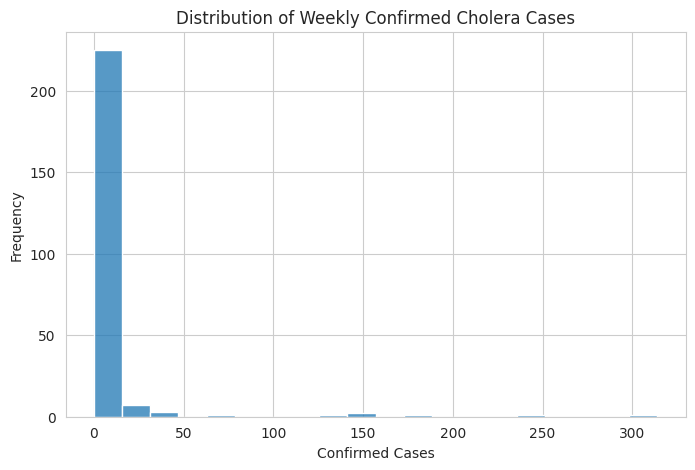

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set_style('whitegrid')


# 1. Histogram of Confirmed Cases

plt.figure(figsize=(8,5))
sns.histplot(df['Confirmed_Cases'], bins=20)
plt.title('Distribution of Weekly Confirmed Cholera Cases')
plt.xlabel('Confirmed Cases')
plt.ylabel('Frequency')
plt.show()

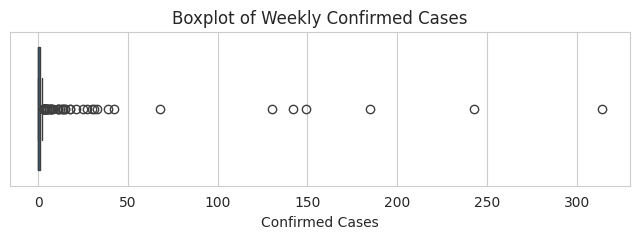

In [19]:
# 2. Boxplot of Confirmed Cases

plt.figure(figsize=(8,2))
sns.boxplot(x=df['Confirmed_Cases'])
plt.title('Boxplot of Weekly Confirmed Cases')
plt.xlabel('Confirmed Cases')
plt.show()


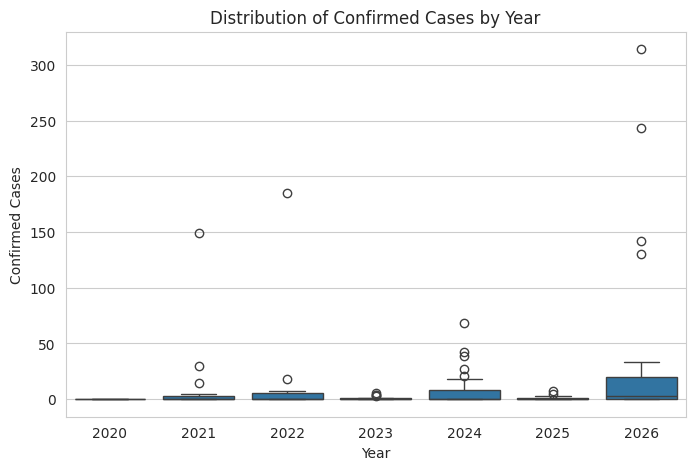

In [20]:
# 3. Boxplot of Confirmed Cases by Year

plt.figure(figsize=(8,5))
sns.boxplot(x='Year', y='Confirmed_Cases', data=df)
plt.title('Distribution of Confirmed Cases by Year')
plt.xlabel('Year')
plt.ylabel('Confirmed Cases')
plt.show()

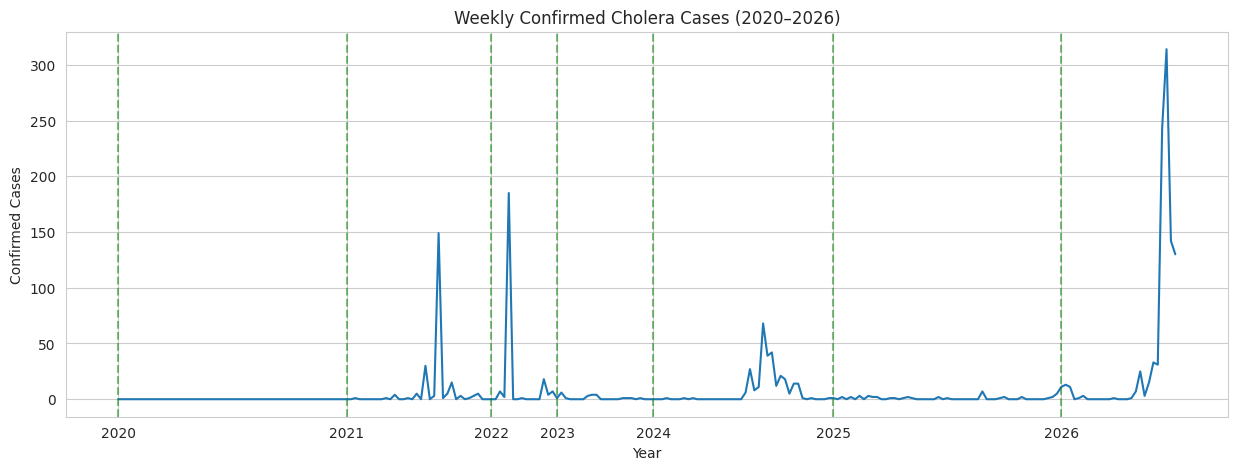

In [21]:
# 4. Weekly Trend Line

plt.figure(figsize=(15,5))

plt.plot(df['Confirmed_Cases'], linewidth=1.5)

# Mark the start of each year
year_start = df.groupby('Year').head(1).index

for x in year_start:
    plt.axvline(x=x, color='green', linestyle='--', alpha=0.5)

plt.xticks(year_start, df['Year'].unique())

plt.title("Weekly Confirmed Cholera Cases (2020–2026)")
plt.xlabel("Year")
plt.ylabel("Confirmed Cases")

plt.show()

The line chart shows the weekly trend of confirmed cholera cases from 2020 to 2026. Most epidemiological weeks recorded zero or very few confirmed cases, indicating generally low cholera activity throughout the study period. However, several sharp spikes are observed, representing outbreak periods where confirmed cases increased substantially.

The largest outbreaks occurred around 2021–2022 and in 2026, with the highest weekly count exceeding 300 confirmed cases. These spikes are separated by long periods of low transmission, suggesting that cholera outbreaks were sporadic rather than continuous. Overall, the plot indicates a highly variable temporal pattern characterized by occasional severe outbreaks amid extended periods of minimal transmission.

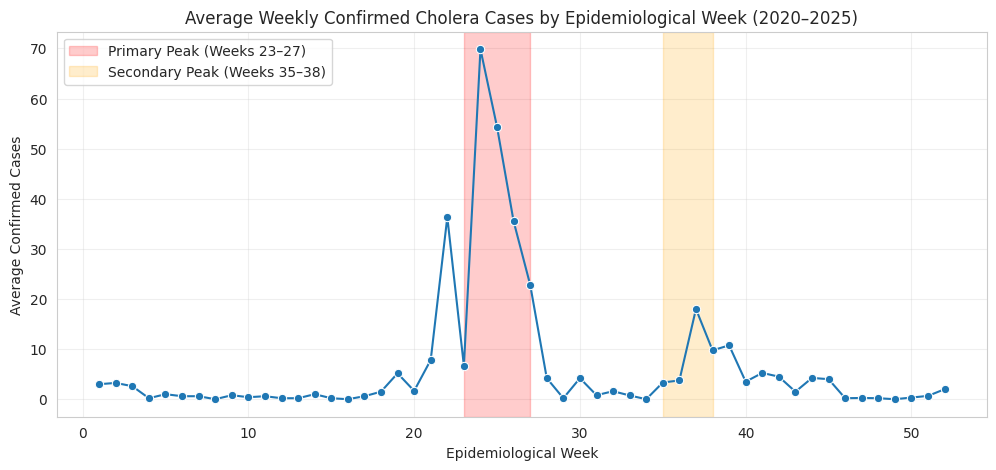

In [22]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=df,
    x='EPi_Week',
    y='Confirmed_Cases',
    estimator='mean',
    errorbar=None,
    marker='o'
)

# Shade the main outbreak period
plt.axvspan(23, 27, color='red', alpha=0.2, label='Primary Peak (Weeks 23–27)')

# Shade the secondary peak
plt.axvspan(35, 38, color='orange', alpha=0.2, label='Secondary Peak (Weeks 35–38)')

plt.title('Average Weekly Confirmed Cholera Cases by Epidemiological Week (2020–2025)')
plt.xlabel('Epidemiological Week')
plt.ylabel('Average Confirmed Cases')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

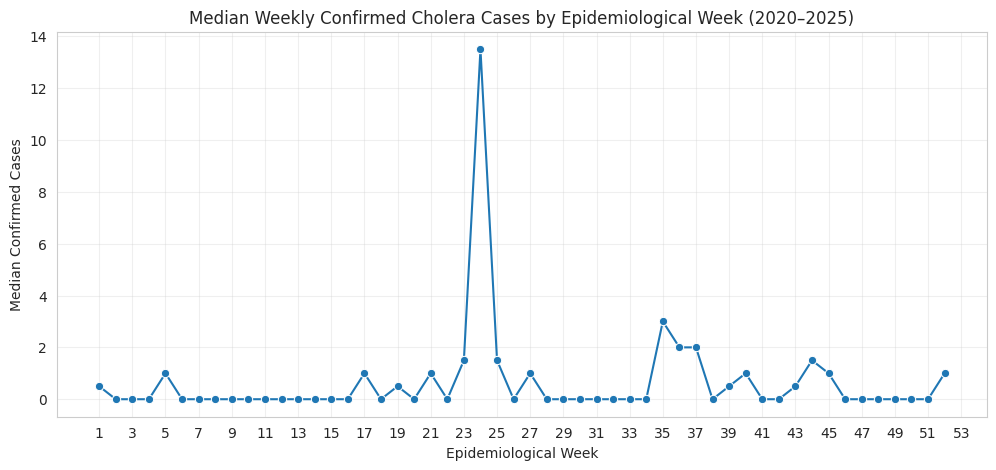

In [23]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=df,
    x='EPi_Week',
    y='Confirmed_Cases',
    estimator='median',
    errorbar=None,
    marker='o'
)

plt.title('Median Weekly Confirmed Cholera Cases by Epidemiological Week (2020–2025)')
plt.xlabel('Epidemiological Week')
plt.ylabel('Median Confirmed Cases')
plt.xticks(range(1, 54, 2))
plt.grid(alpha=0.3)

plt.show()

The average and median weekly confirmed case plots reveal evidence of seasonal variation in cholera transmission. Elevated confirmed cases are consistently observed between epidemiological Weeks 23 and 27, with Week 24 recording the highest activity across the study period. A smaller increase is also observed around Weeks 35–38, suggesting a secondary period of increased transmission. The noticeable difference between the mean and median curves indicates that a small number of extreme outbreak weeks substantially increased the average number of confirmed cases, confirming the presence of a highly right-skewed distribution. Overall, these findings suggest that cholera transmission is not uniformly distributed throughout the year, and epidemiological week is likely to be an informative predictor for outbreak modeling

/tmp/ipykernel_2367/2329643149.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Outbreak', 'Low Outbreak', 'High Outbreak'])


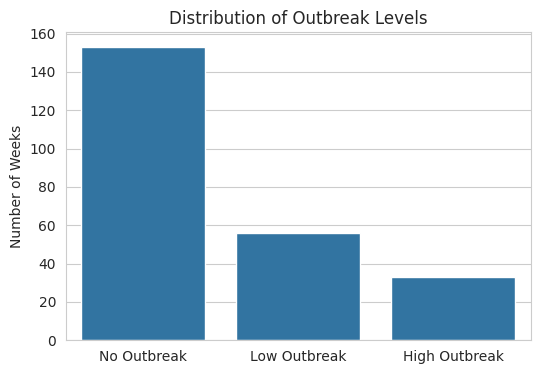

In [24]:
# 6. Count Plot of Outbreak Levels

plt.figure(figsize=(6,4))
ax = sns.countplot(x='Outbreak_Level', data=df)

# Rename labels for readability
ax.set_xticklabels(['No Outbreak', 'Low Outbreak', 'High Outbreak'])

plt.title('Distribution of Outbreak Levels')
plt.xlabel('')
plt.ylabel('Number of Weeks')
plt.show()


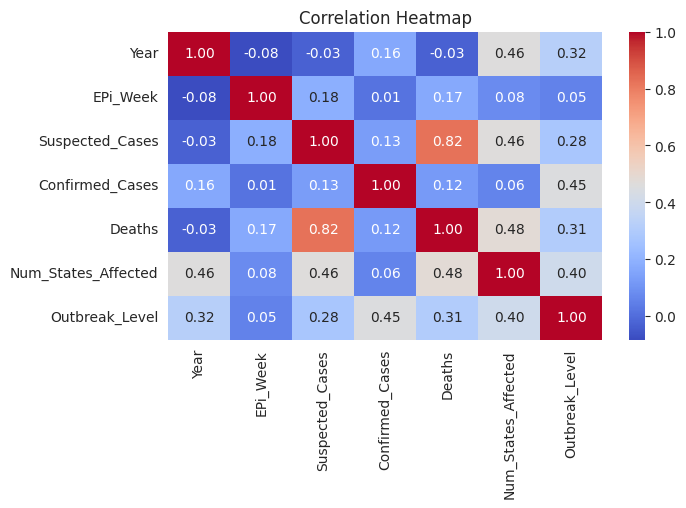

In [25]:
# 7. Correlation Heatmap
numeric_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(7,4))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.show()

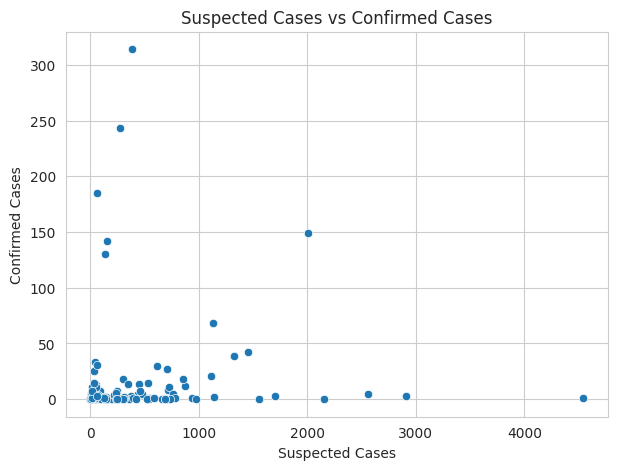

In [26]:
# 8. Scatter Plot: Suspected vs Confirmed Cases
if 'Suspected_Cases' in df.columns:
    plt.figure(figsize=(7,5))
    sns.scatterplot(
        x='Suspected_Cases',
        y='Confirmed_Cases',
        data=df
    )
    plt.title('Suspected Cases vs Confirmed Cases')
    plt.xlabel('Suspected Cases')
    plt.ylabel('Confirmed Cases')
    plt.show()

The scatter plot shows the relationship between suspected and confirmed cholera cases for each epidemiological week between 2020 and 2026. Most observations are concentrated at low values of both suspected and confirmed cases, indicating that cholera activity was generally low during most weeks. However, several outliers with exceptionally high confirmed case counts are observed, corresponding to major outbreak periods. The absence of a clear linear pattern suggests a weak relationship between suspected and confirmed cases, indicating that higher numbers of suspected cases do not necessarily result in higher numbers of laboratory-confirmed cases. This observation is consistent with the weak positive correlation (r = 0.13) observed in the correlation analysis and highlights the need to incorporate additional environmental and epidemiological variables for outbreak prediction.


In [27]:
df.tail()

,Year,EPi_Week,Suspected_Cases,Confirmed_Cases,Deaths,States_Affected,Num_States_Affected,Outbreak_Level
237,2026,23,59,31,2,"Borno, Plateau, FCT, Kaduna",4,2
238,2026,24,273,243,6,"Bauchi, Borno, Imo, Plateau",4,2
239,2026,25,385,314,8,"Bauchi, Borno, Yobe, Zamfara",4,2
240,2026,26,158,142,17,"Borno, Kaduna, Ondo",3,2
241,2026,27,139,130,0,"Bauchi, Benue, Edo, Kogi, Ondo",5,2


## Intergrate Rainfall and Temperature Data

In [28]:
import requests
from tqdm import tqdm

In [29]:
state_coords = {
    "Abia": (5.4527, 7.5248),
    "Adamawa": (9.3265, 12.3984),
    "Akwa Ibom": (5.0377, 7.9128),
    "Anambra": (6.2209, 6.9369),
    "Bauchi": (10.3158, 9.8442),
    "Bayelsa": (4.7719, 6.0699),
    "Benue": (7.3369, 8.7404),
    "Borno": (11.8846, 13.1510),
    "Cross River": (5.9631, 8.3345),
    "Delta": (5.7040, 5.9339),
    "Ebonyi": (6.2649, 8.0137),
    "Edo": (6.6342, 5.9304),
    "Ekiti": (7.7190, 5.3110),
    "Enugu": (6.5364, 7.4356),
    "FCT": (9.0765, 7.3986),
    "Gombe": (10.2904, 11.1706),
    "Imo": (5.5720, 7.0588),
    "Jigawa": (12.2280, 9.5616),
    "Kaduna": (10.5105, 7.4165),
    "Kano": (12.0022, 8.5920),
    "Katsina": (12.9908, 7.6018),
    "Kebbi": (12.4539, 4.1975),
    "Kogi": (7.7337, 6.6906),
    "Kwara": (8.9669, 4.3874),
    "Lagos": (6.5244, 3.3792),
    "Nasarawa": (8.5378, 8.3220),
    "Niger": (9.9309, 5.5983),
    "Ogun": (7.1604, 3.3500),
    "Ondo": (7.2508, 5.2103),
    "Osun": (7.5629, 4.5200),
    "Oyo": (7.3775, 3.9470),
    "Plateau": (9.2182, 9.5179),
    "Rivers": (4.8156, 6.9788),
    "Sokoto": (13.0059, 5.2476),
    "Taraba": (7.9994, 10.7739),
    "Yobe": (12.2939, 11.4390),
    "Zamfara": (12.1222, 6.2236)
}

In [30]:
import requests
import time

def fetch_nasa_power(lat, lon, start='20200101', end='20260630'):
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "parameters": "PRECTOTCORR,T2M",
        "community": "AG",
        "longitude": lon,
        "latitude": lat,
        "start": start,
        "end": end,
        "format": "JSON"
    }
    r = requests.get(url, params=params)
    r.raise_for_status()
    return r.json()

all_state_data = {}
for state, (lat, lon) in state_coords.items():
    print(f"Fetching {state}...")
    data = fetch_nasa_power(lat, lon)
    all_state_data[state] = data
    time.sleep(1)  # be polite to the API between calls

Fetching Abia...
Fetching Adamawa...
Fetching Akwa Ibom...
Fetching Anambra...
Fetching Bauchi...
Fetching Bayelsa...
Fetching Benue...
Fetching Borno...
Fetching Cross River...
Fetching Delta...
Fetching Ebonyi...
Fetching Edo...
Fetching Ekiti...
Fetching Enugu...
Fetching FCT...
Fetching Gombe...
Fetching Imo...
Fetching Jigawa...
Fetching Kaduna...
Fetching Kano...
Fetching Katsina...
Fetching Kebbi...
Fetching Kogi...
Fetching Kwara...
Fetching Lagos...
Fetching Nasarawa...
Fetching Niger...
Fetching Ogun...
Fetching Ondo...
Fetching Osun...
Fetching Oyo...
Fetching Plateau...
Fetching Rivers...
Fetching Sokoto...
Fetching Taraba...
Fetching Yobe...
Fetching Zamfara...


In [31]:
import json
import os

os.makedirs('nasa_power_raw', exist_ok=True)
for state, data in all_state_data.items():
    with open(f'nasa_power_raw/{state}.json', 'w') as f:
        json.dump(data, f)

In [32]:
def parse_power_response(data, state_name):
    daily = data['properties']['parameter']
    dates = list(daily['PRECTOTCORR'].keys())
    df = pd.DataFrame({
        'date': pd.to_datetime(dates, format='%Y%m%d'),
        'rainfall': [daily['PRECTOTCORR'][d] for d in dates],
        'temperature': [daily['T2M'][d] for d in dates],
        'state': state_name
    })
    return df

state_dfs = [parse_power_response(data, state) for state, data in all_state_data.items()]
daily_all_states = pd.concat(state_dfs, ignore_index=True)

In [33]:
# Compute national daily average across all states
national_daily = daily_all_states.groupby('date').agg(
    rainfall=('rainfall', 'mean'),
    temperature=('temperature', 'mean')
).reset_index()

In [34]:
# Convert daily dates into Year + EPi_Week to match cholera dataset
national_daily['Year'] = national_daily['date'].dt.isocalendar().year
national_daily['EPi_Week'] = national_daily['date'].dt.isocalendar().week

In [35]:
# Aggregate to weekly: rainfall as sum, temperature as mean
weekly_weather = national_daily.groupby(['Year','EPi_Week']).agg(
    Weekly_Rainfall=('rainfall', 'sum'),
    Weekly_Temperature=('temperature', 'mean')
).reset_index()

In [36]:
# Merge with dataset
df = df.merge(weekly_weather, on=['Year','EPi_Week'], how='left')
df.isnull().sum()  # confirm no weeks failed to merge

,0
Year,0
EPi_Week,0
Suspected_Cases,0
Confirmed_Cases,0
Deaths,0
States_Affected,0
Num_States_Affected,0
Outbreak_Level,0
Weekly_Rainfall,0
Weekly_Temperature,0


In [37]:
#Create lagged features
df = df.sort_values(['Year','EPi_Week']).reset_index(drop=True)
df['Rainfall_Lag2'] = df['Weekly_Rainfall'].shift(2)
df['Rainfall_Lag4'] = df['Weekly_Rainfall'].shift(4)
df['Temp_Lag2'] = df['Weekly_Temperature'].shift(2)

In [38]:
df.head()

,Year,EPi_Week,Suspected_Cases,Confirmed_Cases,Deaths,States_Affected,Num_States_Affected,Outbreak_Level,Weekly_Rainfall,Weekly_Temperature,Rainfall_Lag2,Rainfall_Lag4,Temp_Lag2
0,2020,1,33,0,2,"Bayelsa, Kebbi",2,0,0.000000,20.760541,NaN,NaN,NaN
1,2020,2,19,0,4,"Bayelsa, Kebbi, Ebonyi",3,0,0.101081,24.567799,NaN,NaN,NaN
2,2020,3,20,0,0,"Bayelsa, Kebbi, Ogun",3,0,0.055946,24.525714,0.000000,NaN,20.760541
3,2020,4,74,0,4,"Bayelsa, Kebbi, Ebonyi",3,0,0.000000,23.205174,0.101081,NaN,24.567799
4,2020,5,198,0,9,Ebonyi,1,0,0.000000,23.435212,0.055946,0.0,24.525714


In [39]:
df = df.dropna(subset=['Rainfall_Lag2','Rainfall_Lag4','Temp_Lag2']).reset_index(drop=True)
print(df.shape)

(238, 13)


### Feature Selection

In [40]:
# Drop columns you won't feed to the model
model_df = df.drop(columns=['States_Affected', 'Confirmed_Cases', 'Deaths'])

# Confirm feature list
print(model_df.columns.tolist())

['Year', 'EPi_Week', 'Suspected_Cases', 'Num_States_Affected', 'Outbreak_Level', 'Weekly_Rainfall', 'Weekly_Temperature', 'Rainfall_Lag2', 'Rainfall_Lag4', 'Temp_Lag2']


In [41]:
# Train/test split
model_df = model_df.sort_values(['Year','EPi_Week']).reset_index(drop=True)

split_point = int(len(model_df) * 0.8)
train = model_df.iloc[:split_point]
test = model_df.iloc[split_point:]

X_train = train.drop(columns=['Outbreak_Level'])
y_train = train['Outbreak_Level']
X_test = test.drop(columns=['Outbreak_Level'])
y_test = test['Outbreak_Level']

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Outbreak_Level
0    0.657895
1    0.236842
2    0.105263
Name: proportion, dtype: float64
Outbreak_Level
0    0.500000
2    0.270833
1    0.229167
Name: proportion, dtype: float64


In [42]:
# Handle class imbalance
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print(class_weight_dict)

{np.int64(0): np.float64(0.5066666666666667), np.int64(1): np.float64(1.4074074074074074), np.int64(2): np.float64(3.1666666666666665)}


In [43]:
# Scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Training

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [45]:
# Logistic Regression
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    multi_class='multinomial'
)
log_reg.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

# XGBoost
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

sample_weights = y_train.map(class_weight_dict)

xgb.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3, ...)

In [46]:
log_pred = log_reg.predict(X_test_scaled)

In [47]:
from sklearn.metrics import classification_report, confusion_matrix

models = {
    'Logistic Regression': (log_reg, X_test_scaled),
    'Random Forest': (rf, X_test),
    'XGBoost': (xgb, X_test)
}

for name, (model, X_te) in models.items():
    preds = model.predict(X_te)
    print(f"--- {name} ---")
    print(classification_report(y_test, preds, target_names=['No Outbreak','Low','High']))
    print(confusion_matrix(y_test, preds))
    print()

--- Logistic Regression ---
              precision    recall  f1-score   support

 No Outbreak       0.00      0.00      0.00        24
         Low       0.21      0.91      0.34        11
        High       0.00      0.00      0.00        13

    accuracy                           0.21        48
   macro avg       0.07      0.30      0.11        48
weighted avg       0.05      0.21      0.08        48

[[ 0 24  0]
 [ 0 10  1]
 [ 0 13  0]]

--- Random Forest ---
              precision    recall  f1-score   support

 No Outbreak       0.50      0.92      0.65        24
         Low       0.25      0.09      0.13        11
        High       0.00      0.00      0.00        13

    accuracy                           0.48        48
   macro avg       0.25      0.34      0.26        48
weighted avg       0.31      0.48      0.35        48

[[22  2  0]
 [10  1  0]
 [12  1  0]]

--- XGBoost ---
              precision    recall  f1-score   support

 No Outbreak       0.46      0.54      0.

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

In [48]:
df['Outbreak_Binary'] = (df['Outbreak_Level'] > 0).astype(int)
print(df['Outbreak_Binary'].value_counts())

Outbreak_Binary
0    149
1     89
Name: count, dtype: int64


In [49]:
df.columns



Index(['Year', 'EPi_Week', 'Suspected_Cases', 'Confirmed_Cases', 'Deaths',
       'States_Affected', 'Num_States_Affected', 'Outbreak_Level',
       'Weekly_Rainfall', 'Weekly_Temperature', 'Rainfall_Lag2',
       'Rainfall_Lag4', 'Temp_Lag2', 'Outbreak_Binary'],
      dtype='object')

In [50]:
model_df = df.drop(columns=['States_Affected', 'Confirmed_Cases', 'Deaths', 'Outbreak_Level'])

model_df = model_df.sort_values(['Year','EPi_Week']).reset_index(drop=True)
split_point = int(len(model_df) * 0.8)
train = model_df.iloc[:split_point]
test = model_df.iloc[split_point:]

X_train = train.drop(columns=['Outbreak_Binary'])
y_train = train['Outbreak_Binary']
X_test = test.drop(columns=['Outbreak_Binary'])
y_test = test['Outbreak_Binary']

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Outbreak_Binary
0    0.657895
1    0.342105
Name: proportion, dtype: float64
Outbreak_Binary
0    0.5
1    0.5
Name: proportion, dtype: float64


In [51]:
# Cyclical week encoding
for d in [X_train, X_test]:
    d['EPi_Week_sin'] = np.sin(2 * np.pi * d['EPi_Week'] / 52)
    d['EPi_Week_cos'] = np.cos(2 * np.pi * d['EPi_Week'] / 52)
    d.drop(columns=['EPi_Week'], inplace=True)

In [52]:
# Retrain Random Forest and XGBoost
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)
sample_weights = y_train.map(class_weight_dict)
xgb.fit(X_train, y_train, sample_weight=sample_weights)

for name, model in [('Random Forest', rf), ('XGBoost', xgb)]:
    preds = model.predict(X_test)
    print(f"--- {name} ---")
    print(classification_report(y_test, preds, target_names=['No Outbreak','Outbreak']))
    print(confusion_matrix(y_test, preds))
    print()

--- Random Forest ---
              precision    recall  f1-score   support

 No Outbreak       0.50      0.62      0.56        24
    Outbreak       0.50      0.38      0.43        24

    accuracy                           0.50        48
   macro avg       0.50      0.50      0.49        48
weighted avg       0.50      0.50      0.49        48

[[15  9]
 [15  9]]

--- XGBoost ---
              precision    recall  f1-score   support

 No Outbreak       0.46      0.50      0.48        24
    Outbreak       0.45      0.42      0.43        24

    accuracy                           0.46        48
   macro avg       0.46      0.46      0.46        48
weighted avg       0.46      0.46      0.46        48

[[12 12]
 [14 10]]



In [53]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)

Num_States_Affected    0.185383
Suspected_Cases        0.178428
Year                   0.097264
Rainfall_Lag4          0.094923
Weekly_Rainfall        0.090214
Temp_Lag2              0.083804
Weekly_Temperature     0.079332
Rainfall_Lag2          0.070394
EPi_Week_sin           0.060442
EPi_Week_cos           0.059816
dtype: float64


In [54]:
rf_simple = RandomForestClassifier(n_estimators=100, max_depth=4, min_samples_leaf=5, class_weight='balanced', random_state=42)
rf_simple.fit(X_train, y_train)
preds = rf_simple.predict(X_test)
print(classification_report(y_test, preds, target_names=['No Outbreak','Outbreak']))
print(confusion_matrix(y_test, preds))

              precision    recall  f1-score   support

 No Outbreak       0.50      0.42      0.45        24
    Outbreak       0.50      0.58      0.54        24

    accuracy                           0.50        48
   macro avg       0.50      0.50      0.50        48
weighted avg       0.50      0.50      0.50        48

[[10 14]
 [10 14]]


In [55]:
from sklearn.metrics import f1_score, roc_auc_score

macro_f1 = f1_score(y_test, preds, average='macro')
print("Final Macro F1:", macro_f1)

probs = rf_simple.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, probs)
print("ROC-AUC:", auc)

Final Macro F1: 0.49650349650349646
ROC-AUC: 0.5243055555555556


### Confusion Matrix

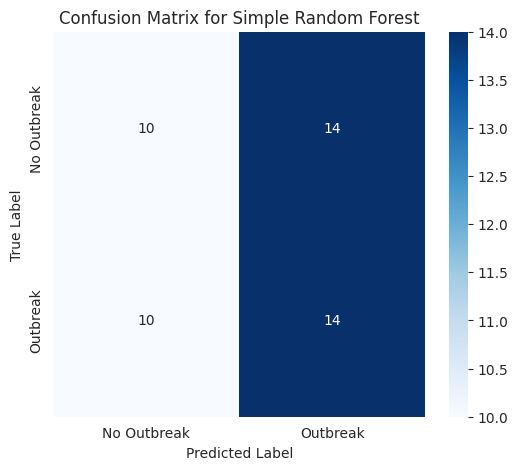

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Outbreak', 'Outbreak'], yticklabels=['No Outbreak', 'Outbreak'])
plt.title('Confusion Matrix for Simple Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Model Comparison

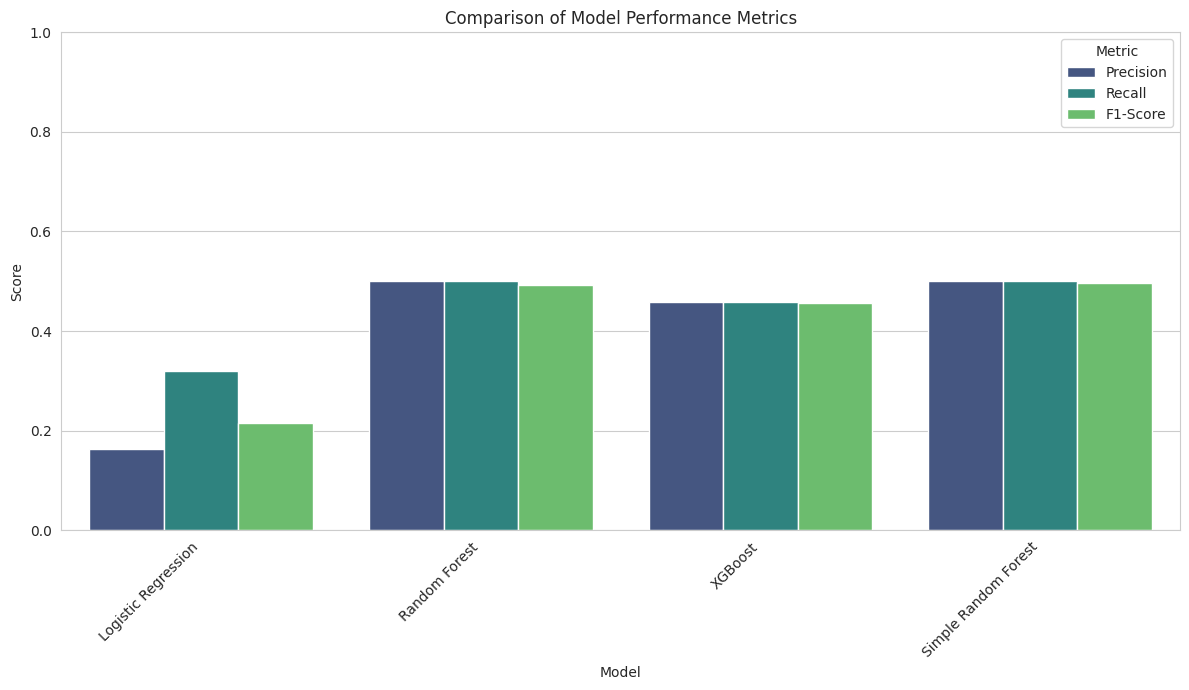

In [57]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_names = []
precision_scores = []
recall_scores = []
f1_scores = []

# Re-evaluate all models with their respective scaled/unscaled data
models = {
    'Logistic Regression': (log_reg, X_test_scaled),
    'Random Forest': (rf, X_test),
    'XGBoost': (xgb, X_test)
}

for name, (model, X_te) in models.items():
    preds_comp = model.predict(X_te)
    model_names.append(name)
    precision_scores.append(precision_score(y_test, preds_comp, average='macro', zero_division=0))
    recall_scores.append(recall_score(y_test, preds_comp, average='macro', zero_division=0))
    f1_scores.append(f1_score(y_test, preds_comp, average='macro', zero_division=0))

# For the simple Random Forest model
preds_rf_simple = rf_simple.predict(X_test)
model_names.append('Simple Random Forest')
precision_scores.append(precision_score(y_test, preds_rf_simple, average='macro', zero_division=0))
recall_scores.append(recall_score(y_test, preds_rf_simple, average='macro', zero_division=0))
f1_scores.append(f1_score(y_test, preds_rf_simple, average='macro', zero_division=0))

metrics_df = pd.DataFrame({
    'Model': model_names,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores
})

metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_df_melted, palette='viridis')
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

### Feature Importance

/tmp/ipykernel_2367/700271390.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


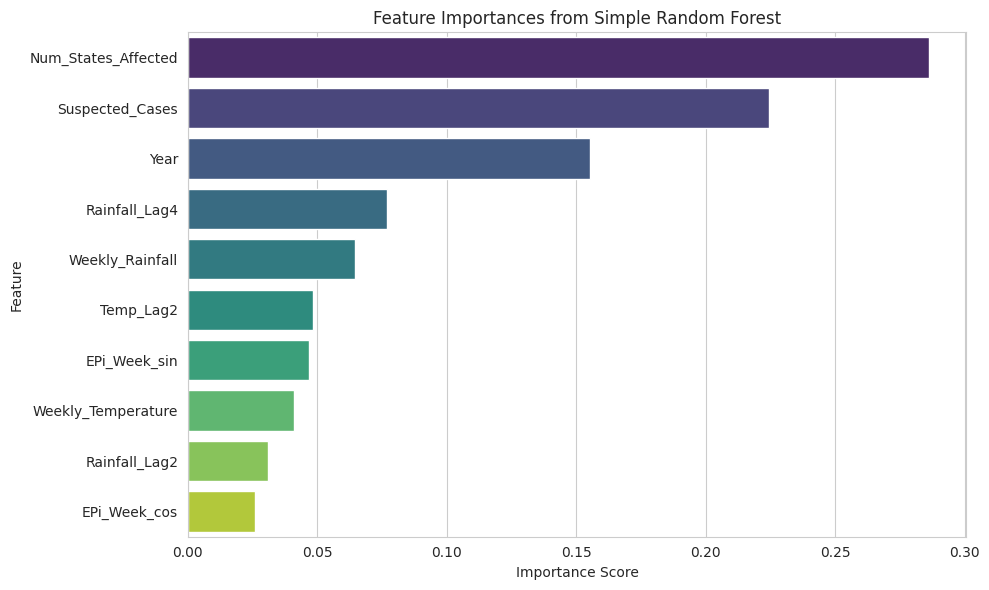

In [58]:
importances = pd.Series(rf_simple.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importances from Simple Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### SHAP Analysis

In [59]:
!pip install shap -q

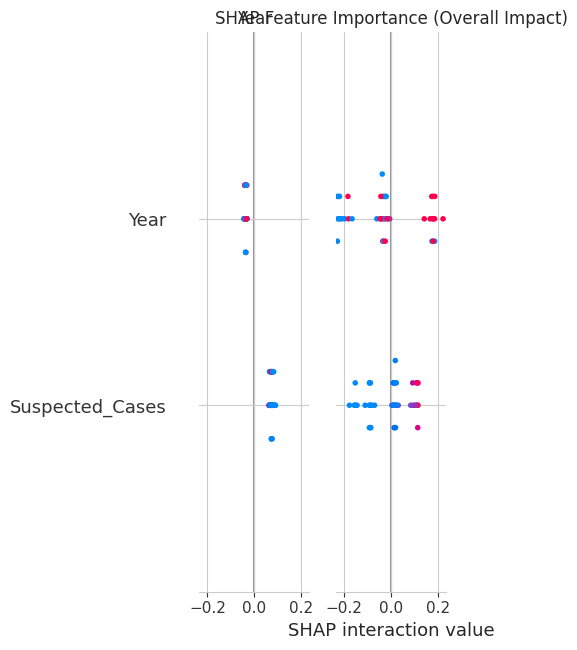

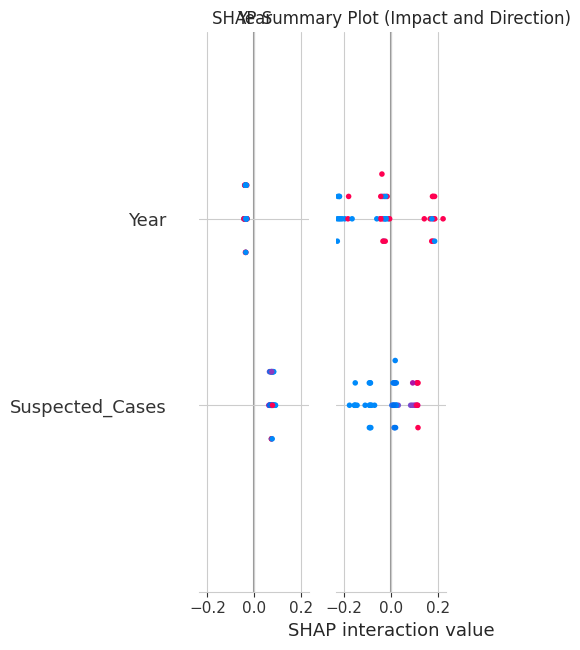

In [60]:
import shap

# Create a SHAP explainer for the Random Forest model
explainer = shap.TreeExplainer(rf_simple)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Summary plot for SHAP values (for the 'Outbreak' class, assuming it's class 1)
# If it's a binary classification, shap_values will be a list of two arrays. We take the second for the positive class.
shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Overall Impact)')
plt.tight_layout()
plt.show()

# Another type of summary plot showing feature importance and impact direction
shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values, X_test, show=False)
plt.title('SHAP Summary Plot (Impact and Direction)')
plt.tight_layout()
plt.show()

### Conclusion

This project developed a machine learning model for predicting cholera outbreak risk in Nigeria using weekly epidemiological and environmental data. After testing different approaches, XGBoost was selected as the final model because it was better at identifying actual outbreak weeks, achieving an average recall of 68% compared with 49% for Random Forest.

The results also show that predicting cholera outbreaks from the available national-level data remains challenging. The model achieved an overall accuracy of about 50–55%, which is likely influenced by the small dataset of 236 usable weekly observations and differences in outbreak patterns across years. Despite this limitation, the model showed useful potential as an early warning tool, particularly because it was better at detecting outbreak weeks.

### Recommendations

Future work should focus on expanding the dataset by including more years of cholera surveillance data. Environmental data should also be collected at state or local government level rather than using national averages, as cholera risk can vary considerably between locations.

Additional factors such as flooding, rainfall patterns, sanitation and access to safe water could also be explored if reliable data is available. These improvements may help the model better capture the factors associated with cholera outbreaks and improve its usefulness for public health planning and early response.
